In [1]:
from shared.utils.reproducibility import set_seeds

set_seeds(seed=43)

In [2]:
import os

BASE_PATH = "C:/Users/panaa/Desktop/engagenet"

TRAIN_ENGAGENET = os.path.join(BASE_PATH, "train")
VAL_ENGAGENET = os.path.join(BASE_PATH, "val")
TEST_ENGAGENET = os.path.join(BASE_PATH, "test")

In [3]:
import os
from collections import Counter

def get_class_distribution(dataset_path: str) -> dict:
    counts = Counter()

    for label_name in os.listdir(dataset_path):
        label_path = os.path.join(dataset_path, label_name)

        num_files = len([
            f for f in os.listdir(label_path)
            if f.endswith(".json")
        ])

        counts[label_name] = num_files

    return dict(counts)


def print_distribution(name: str, dataset_path: str) -> dict:
    dist = get_class_distribution(dataset_path)

    print(f"\n{name} Distribution:")
    for k, v in sorted(dist.items()):
        print(f"{k}: {v}")

    return dist

In [4]:
train_dist = print_distribution("Train", TRAIN_ENGAGENET)
val_dist = print_distribution("Val", VAL_ENGAGENET)
test_dist = print_distribution("Test", TEST_ENGAGENET)


Train Distribution:
Barely-Engaged: 788
Engaged: 1343
Highly-Engaged: 2841
Not-Engaged: 1057

Val Distribution:
Barely-Engaged: 84
Engaged: 193
Highly-Engaged: 435
Not-Engaged: 121

Test Distribution:
Barely-Engaged: 181
Engaged: 335
Highly-Engaged: 896
Not-Engaged: 273


In [5]:
from sklearn.utils import shuffle
from src.engagenet.dataset.dataset import build_dataset

X_train, y_train = build_dataset(TRAIN_ENGAGENET)
X_train, y_train = shuffle(X_train, y_train, random_state=42)

X_val, y_val = build_dataset(VAL_ENGAGENET)
X_test, y_test = build_dataset(TEST_ENGAGENET)

print(X_train.shape)  # (N, 20, ~1434)
print(X_train.shape[1])
print(y_train.shape)  # (N,)

print(X_val.shape)
print(y_val.shape)

print(X_test.shape)
print(y_test.shape)

(6029, 20, 1434)
20
(6029,)
(833, 20, 1434)
(833,)
(1685, 20, 1434)
(1685,)


In [6]:
import numpy as np
import os

min_val = X_train.min(axis=(0,1), keepdims=True)
max_val = X_train.max(axis=(0,1), keepdims=True)

X_train = (X_train - min_val) / (max_val - min_val + 1e-8)
X_val = (X_val - min_val) / (max_val - min_val + 1e-8)
X_test = (X_test - min_val) / (max_val - min_val + 1e-8)

X_train = np.clip(X_train, 0.0, 1.0)
X_val = np.clip(X_val, 0.0, 1.0)
X_test = np.clip(X_test, 0.0, 1.0)

os.makedirs("scaler", exist_ok=True)
np.save("scaler/min.npy", min_val)
np.save("scaler/max.npy", max_val)

print("Train:", X_train.min(), X_train.max())
print("Val:", X_val.min(), X_val.max())
print("Test:", X_test.min(), X_test.max())

Train: 0.0 1.0
Val: 0.0 1.0
Test: 0.0 1.0


In [7]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

def get_class_weights(y: np.ndarray) -> dict:
    classes = np.unique(y)

    weights = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=y
    )

    return dict(zip(classes, weights))


class_weights = get_class_weights(y_train)
print(class_weights)

sample_weights = np.array([class_weights[int(y)] for y in y_train], dtype=np.float32)

{0: 1.4259697256386, 1: 1.912753807106599, 2: 1.122300819061802, 3: 0.5305350228792679}


In [8]:
from engagenet.models.model import build_engagenet_model, compile_model, get_callbacks

model = build_engagenet_model()
compile_model(model)
callbacks = get_callbacks()

model.summary()

Model: "EngageNet"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 inputs (InputLayer)         [(None, 20, 1434)]        0         
                                                                 
 lstm (LSTM)                 (None, 20, 256)           1731584   
                                                                 
 lstm_1 (LSTM)               (None, 128)               197120    
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense (Dense)               (None, 128)               16512     
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 engagenet_output (Dense)    (None, 4)                 26

In [9]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    sample_weight=sample_weights,
    epochs=100,
    batch_size=16,
    callbacks=callbacks,
)

Epoch 1/100
377/377 [==============================] - ETA: 0s - loss: 1.3997 - accuracy: 0.2264
Epoch 1: val_loss improved from inf to 1.36780, saving model to checkpoints\best_model.h5
377/377 [==============================] - 42s 104ms/step - loss: 1.3997 - accuracy: 0.2264 - val_loss: 1.3678 - val_accuracy: 0.5222 - lr: 0.0010
Epoch 2/100
377/377 [==============================] - ETA: 0s - loss: 1.3908 - accuracy: 0.2428
Epoch 2: val_loss did not improve from 1.36780
377/377 [==============================] - 42s 112ms/step - loss: 1.3908 - accuracy: 0.2428 - val_loss: 1.4095 - val_accuracy: 0.1008 - lr: 0.0010
Epoch 3/100
377/377 [==============================] - ETA: 0s - loss: 1.3887 - accuracy: 0.2405
Epoch 3: val_loss did not improve from 1.36780
377/377 [==============================] - 44s 115ms/step - loss: 1.3887 - accuracy: 0.2405 - val_loss: 1.3999 - val_accuracy: 0.1008 - lr: 0.0010
Epoch 4/100
377/377 [==============================] - ETA: 0s - loss: 1.3855 - accu

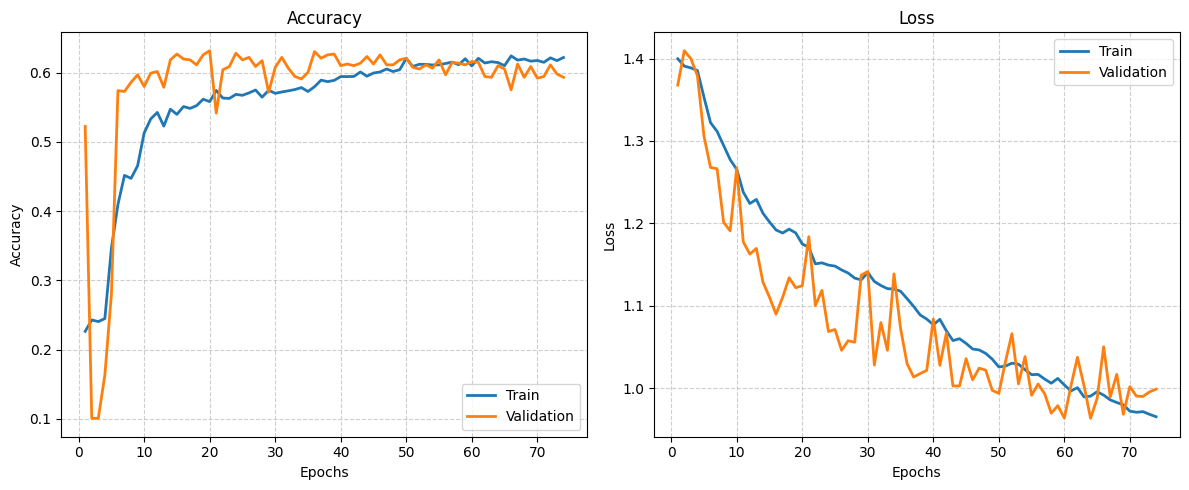

In [10]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs = range(1, len(acc) + 1)

    plt.style.use('default')
    plt.figure(figsize=(12, 5), facecolor='white')

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Train', linewidth=2)
    plt.plot(epochs, val_acc, label='Validation', linewidth=2)
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Train', linewidth=2)
    plt.plot(epochs, val_loss, label='Validation', linewidth=2)
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

plot_training_history(history)


================ TEST METRICS ================

Accuracy : 0.6285
Macro F1 : 0.5021

=========== Classification Report ===========

                precision    recall  f1-score   support

   Not-Engaged       0.63      0.56      0.59       273
Barely-Engaged       0.24      0.25      0.24       181
       Engaged       0.36      0.35      0.36       335
Highly-Engaged       0.80      0.83      0.82       896

      accuracy                           0.63      1685
     macro avg       0.51      0.50      0.50      1685
  weighted avg       0.63      0.63      0.63      1685



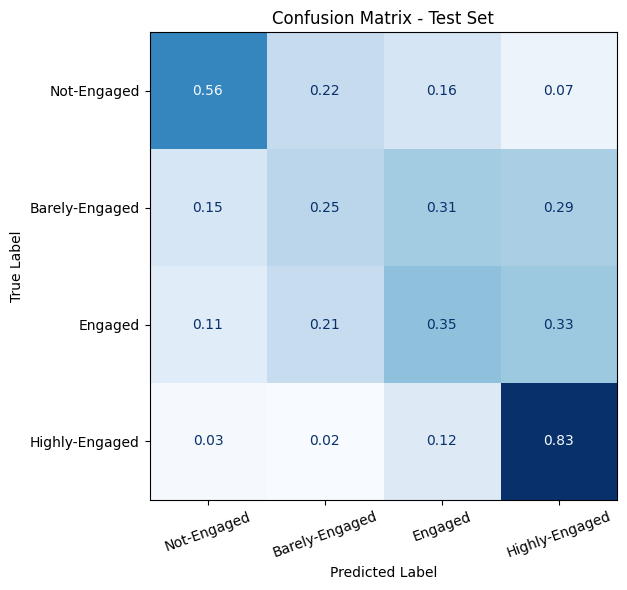

In [11]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score, f1_score)

ENGAGENET_LABELS = ['Not-Engaged', 'Barely-Engaged', 'Engaged', 'Highly-Engaged']

def evaluate_on_test(model, X_test, y_test, class_names=ENGAGENET_LABELS, normalize='true'):
    y_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')

    print("\n================ TEST METRICS ================\n")
    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1 : {macro_f1:.4f}")


    print("\n=========== Classification Report ===========\n")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=2))

    cm = confusion_matrix(y_test, y_pred, normalize=normalize)

    fig, ax = plt.subplots(figsize=(7, 6), facecolor='white')

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        ax=ax,
        cmap='Blues',
        values_format='.2f',
        colorbar=False
    )

    plt.title('Confusion Matrix - Test Set')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.xticks(rotation=20)
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

    return y_pred, y_prob

y_pred, y_prob = evaluate_on_test(model, X_test, y_test)